In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import seaborn as sns
np.random.seed(228)
n = 25
sample = np.random.exponential(scale=1, size=n)
for i in range(sample.size):
    if (sample[i]>1):
        sample[i] = 0
print("Сгенерированная выборка:")
print(sample)

Сгенерированная выборка:
[0.55131922 0.78032461 0.         0.42477489 0.57808608 0.88928151
 0.         0.11683255 0.15420378 0.         0.41098299 0.07157792
 0.37384921 0.94876388 0.         0.         0.09770507 0.
 0.20101658 0.05028214 0.29134768 0.20173255 0.58180903 0.
 0.34483741]


In [ ]:
median_sample = np.median(sample)
range_sample = np.max(sample) - np.min(sample)
skew_sample = stats.skew(sample)
mode_sample = stats.mode(sample)
print(f"Медиана: {median_sample:.4f}")
print(f"Размах: {range_sample:.4f}")
print(f"Коэффициент асимметрии: {skew_sample:.4f}")
if (mode_sample.count != 1):
    print(f"Мода: {mode_sample.mode:.4f}, {mode_sample.count:.4f}")
else:
    print("Моды нет")

Медиана: 0.2010
Размах: 0.9488
Коэффициент асимметрии: 0.8591
Мода: 0.0000,7.0000


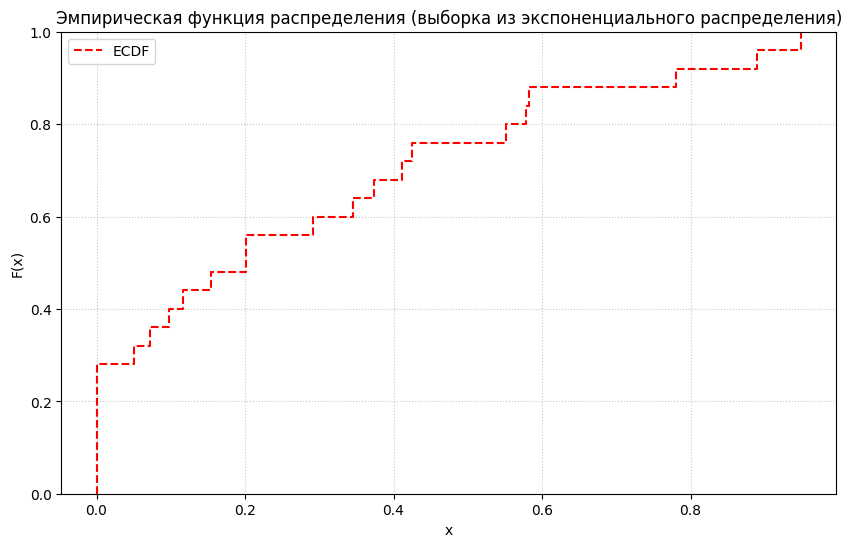

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.ecdf(sample, label='ECDF', linestyle='--', color='red')
ax.set_title('Эмпирическая функция распределения (выборка из экспоненциального распределения)')
ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()
plt.show()

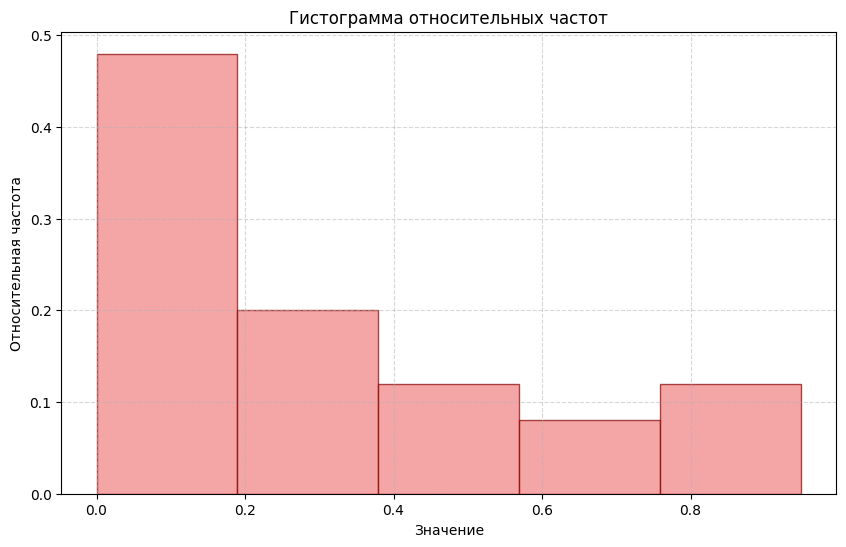

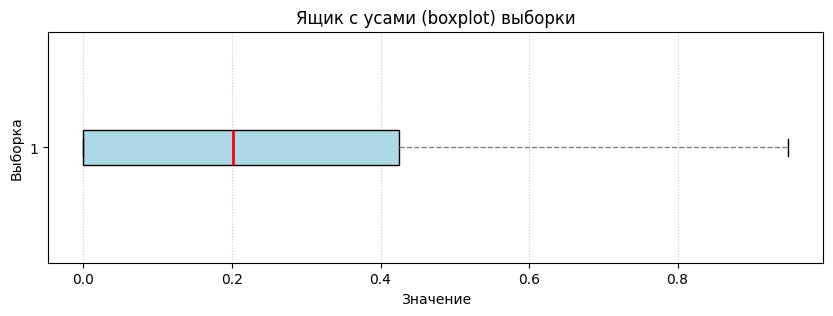

In [9]:
n = len(sample)
bins = int(1 + math.log2(n))

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(sample, bins=bins, 
        weights=np.ones_like(sample) / n,
        color='lightcoral', edgecolor='darkred', alpha=0.7, rwidth=1.0)
ax.set_title('Гистограмма относительных частот')
ax.set_xlabel('Значение')
ax.set_ylabel('Относительная частота')
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(sample, vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='gray', linestyle='--'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=5, alpha=0.6))
ax.set_title('Ящик с усами (boxplot) выборки')
ax.set_xlabel('Значение')
ax.set_ylabel('Выборка')
ax.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.show()

Выборочное среднее = 0.283
Стандартная ошибка = 0.059


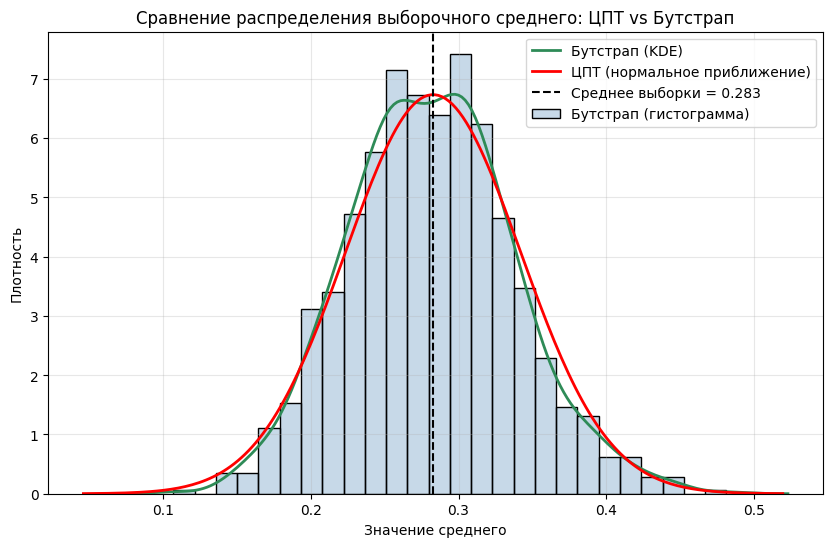

In [12]:
n = len(sample)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
std_error = sample_std / np.sqrt(n)

print(f"Выборочное среднее = {sample_mean:.3f}")
print(f"Стандартная ошибка = {std_error:.3f}")

n_bootstrap = 1000
rng = np.random.default_rng()
bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    boot_sample = rng.choice(sample, size=n, replace=True)
    bootstrap_means[i] = np.mean(boot_sample)

ci_percentiles = np.percentile(bootstrap_means, [2.5, 97.5])
ci_normal = (sample_mean - 1.96*std_error, sample_mean + 1.96*std_error)

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(bootstrap_means, stat='density', alpha=0.3, 
             label='Бутстрап (гистограмма)', color='steelblue', ax=ax)
sns.kdeplot(bootstrap_means, label='Бутстрап (KDE)', 
            color='seagreen', linewidth=2, ax=ax)

x = np.linspace(sample_mean - 4*std_error, sample_mean + 4*std_error, 200)
normal_pdf = stats.norm.pdf(x, loc=sample_mean, scale=std_error)
ax.plot(x, normal_pdf, 'r-', linewidth=2, label='ЦПТ (нормальное приближение)')

ax.axvline(sample_mean, color='black', linestyle='--', 
           label=f'Среднее выборки = {sample_mean:.3f}')

ax.set_title('Сравнение распределения выборочного среднего: ЦПТ vs Бутстрап')
ax.set_xlabel('Значение среднего')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

Первые 10 бутстраповских значений: [1.08623172 0.6265426  0.51464587 0.74910178 0.31665459 0.64347039
 0.70285644 0.65777605 0.8073565  1.10759328]


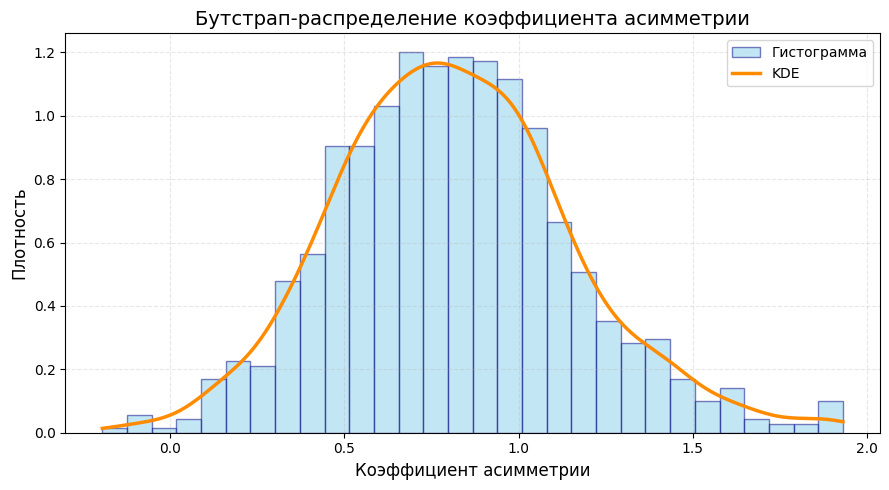

Оценка вероятности P(skewness < 1) = 0.7270


In [ ]:
B = 1000
n = len(sample)

boot_skew = np.zeros(B)

for i in range(B):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    boot_skew[i] = stats.skew(boot_sample)

print("Первые 10 бутстраповских значений:", boot_skew[:10])

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(boot_skew, bins=30, density=True, alpha=0.5,
        color='skyblue', edgecolor='navy', label='Гистограмма')

kde = stats.gaussian_kde(boot_skew)
x_grid = np.linspace(boot_skew.min(), boot_skew.max(), 200)
ax.plot(x_grid, kde(x_grid), color='darkorange', lw=2.5, label='Ядерная оценка плотности')

ax.set_title('Бутстрап-распределение коэффициента асимметрии', fontsize=14)
ax.set_xlabel('Коэффициент асимметрии', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.legend()
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

prob_less_1 = np.mean(boot_skew < 1)
print(f"Оценка вероятности P(skewness < 1) = {prob_less_1:.4f}")

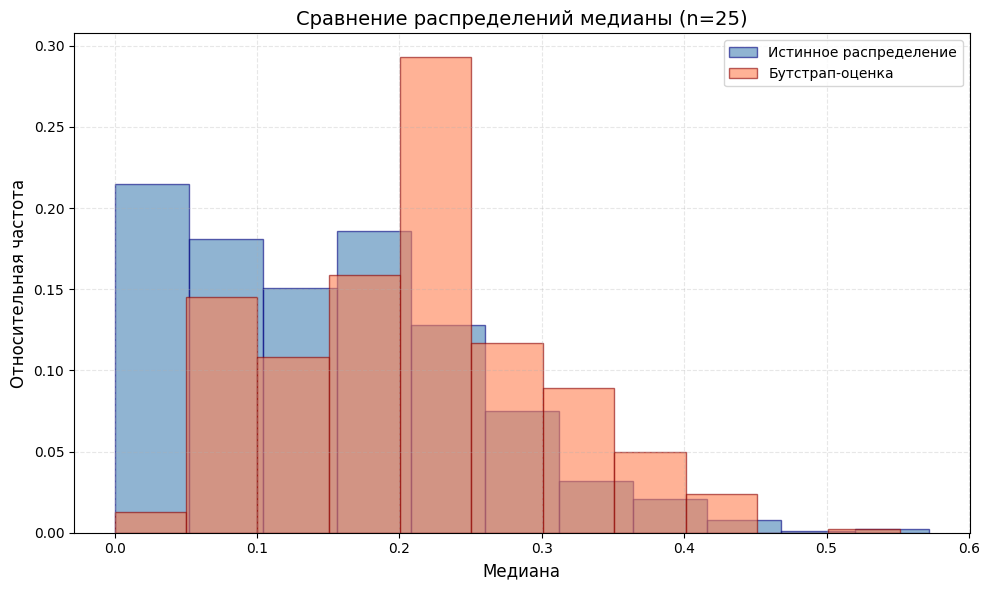

In [15]:
n = 25
B = 1000
R = 1000

true_medians = []
for _ in range(B):
    x = np.random.exponential(scale=1, size=n)
    x[x > 1] = 0
    true_medians.append(np.median(x))
true_medians = np.array(true_medians)

bootstrap_medians = []
for _ in range(R):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    bootstrap_medians.append(np.median(boot_sample))
bootstrap_medians = np.array(bootstrap_medians)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(true_medians, bins=11, 
        weights=np.ones_like(true_medians) / B,
        alpha=0.6, color='steelblue', edgecolor='navy', rwidth=1.0,
        label='Истинное распределение')
ax.hist(bootstrap_medians, bins=11,
        weights=np.ones_like(bootstrap_medians) / R,
        alpha=0.6, color='coral', edgecolor='darkred', rwidth=1.0,
        label='Бутстрап-оценка')

ax.set_xlabel('Медиана', fontsize=12)
ax.set_ylabel('Относительная частота', fontsize=12)
ax.set_title('Сравнение распределений медианы (n=25)', fontsize=14)
ax.legend()
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()